# Binomial option pricing

Cox-Ross-Rubinstein tree for European and American options. Prices are checked against put-call parity and a Black-Scholes closed form.

In [358]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

## 1. Binomial model

### 1.1 European options

Each step, the stock moves up by $u = e^{\sigma\sqrt{\Delta t}}$ or down by $d = 1/u$, with $\Delta t = T/n$. The up probability

$$p = \frac{e^{r\Delta t} - d}{u - d}$$

is chosen so the stock earns the risk-free rate on average. Pricing goes backwards: the payoff at maturity is known, and every node is the discounted expectation of its two children.

The function returns the price and the hedge ratio:

$$\Delta = \frac{C_u - C_d}{S_0 (u - d)}$$

In [359]:
def european_option_binomial_model(
    S0: float, K: float, n: int, T: float, sigma: float, r: float, option_type: str
) -> tuple[float, float]:
    """
    CRR binomial tree: price of a European call ("c") or put ("p").
    """
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # risk-neutral probability

    j = np.arange(n + 1)
    S_T = S0 * u**j * d ** (n - j)  # asset prices at maturity

    # Option payoff at maturity, then discounted backwards
    if option_type == "c":
        C = np.maximum(S_T - K, np.zeros(n + 1))  # call payoff
    elif option_type == "p":
        C = np.maximum(K - S_T, np.zeros(n + 1))  # put payoff
    else:
        raise ValueError("option_type must be 'c' or 'p'")

    for i in np.arange(n, 0, -1):
        if len(C) == 2:  # last pair of nodes: compute the hedge ratio
            delta = (C[1] - C[0]) / (S0 * (u - d))  # hedge ratio
        C = np.exp(-r * dt) * (p * C[1 : i + 1] + (1 - p) * C[0:i])

    return C[0], delta

In [360]:
(
    round(
        european_option_binomial_model(
            S0=100, K=100, n=5000, T=1, sigma=0.2, r=0.05, option_type="c"
        )[0],
        4,
    ),
    round(
        european_option_binomial_model(
            S0=100, K=100, n=5000, T=1, sigma=0.2, r=0.05, option_type="c"
        )[1],
        4,
    ),
)

(np.float64(10.4502), np.float64(0.6368))

### 1.2 American options

An American option can be exercised at any time, not just at maturity. At each node we keep the option or exercise it, whichever is worth more:

$$C = \max (e^{-r\Delta t}(p C_u + (1-p) C_d), \text{payoff at the node})$$

Black-Scholes only prices European options. There is no closed form for the American put.

In [361]:
def american_option_binomial_model(
    S0: float, K: float, n: int, T: float, sigma: float, r: float, option_type: str
) -> float:
    """
    CRR binomial tree: price of an American call ("c") or put ("p").
    """
    dt = T / n
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r * dt) - d) / (u - d)  # risk-neutral probability

    j = np.arange(n + 1)
    S_T = S0 * u**j * d ** (n - j)  # asset prices at maturity

    # Option payoff at maturity
    if option_type == "p":
        C = np.maximum(K - S_T, np.zeros(n + 1))  # put payoff
    elif option_type == "c":
        C = np.maximum(S_T - K, np.zeros(n + 1))  # call payoff
    else:
        raise ValueError("option_type must be 'c' or 'p'")

    for i in np.arange(n, 0, -1):
        j_i = np.arange(i)
        S_i = S0 * u**j_i * d ** ((i - 1) - j_i)  # lattice prices one step before i
        binomial_value = np.exp(-r * dt) * (p * C[1 : i + 1] + (1 - p) * C[0:i])

        # American feature: keep the best of holding or intrinsic early
        if option_type == "p":
            intrinsic_value = np.maximum(K - S_i, np.zeros(i))  # put intrinsic value
        elif option_type == "c":
            intrinsic_value = np.maximum(S_i - K, np.zeros(i))  # call intrinsic value

        C = np.maximum(binomial_value, intrinsic_value)

    return C[0]

In [362]:
round(
    american_option_binomial_model(
        S0=100, K=100, n=5000, T=1, sigma=0.2, r=0.05, option_type="p"
    ),
    4,
)

np.float64(6.0902)

## 2. Verification and convergence

### 2.1 Put-call parity

A call and a put with the same strike and maturity are linked by

$$C - P = S_0 - Ke^{-rT}$$

The tree should reproduce this exactly.


In [363]:
call = european_option_binomial_model(
    S0=100, K=100, n=5000, T=1, sigma=0.2, r=0.05, option_type="c"
)[0]
put = european_option_binomial_model(
    S0=100, K=100, n=5000, T=1, sigma=0.2, r=0.05, option_type="p"
)[0]
round(call - put, 4), round(100 - 100 * np.exp(-0.05 * 1), 4)

(np.float64(4.8771), np.float64(4.8771))

### 2.2 Black-Scholes reference

We use the Black-Scholes model as a benchmark.

The function returns the price and the hedge ratio $N(d_1)$ for a call, $-N(-d_1)$ for a put.


In [364]:
def black_scholes_option_pricer(
    S0: float, K: float, T: float, sigma: float, r: float, option_type: str
) -> tuple[float, float]:
    """
    Closed-form Black-Scholes price and hedge delta of a call ("c") or put ("p").
    """
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "c":
        price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        delta = norm.cdf(d1)
    elif option_type == "p":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)
        delta = -norm.cdf(-d1)
    else:
        raise ValueError("option_type must be 'c' or 'p'")

    return price, delta

In [365]:
(
    round(
        black_scholes_option_pricer(
            S0=100, K=100, T=1, sigma=0.2, r=0.05, option_type="c"
        )[0],
        4,
    ),
    round(
        black_scholes_option_pricer(
            S0=100, K=100, T=1, sigma=0.2, r=0.05, option_type="c"
        )[1],
        4,
    ),
)

(np.float64(10.4506), np.float64(0.6368))

### 2.3 Convergence

As $n$ grows, the tree price approaches the Black-Scholes price. The error decays like $1/n$.


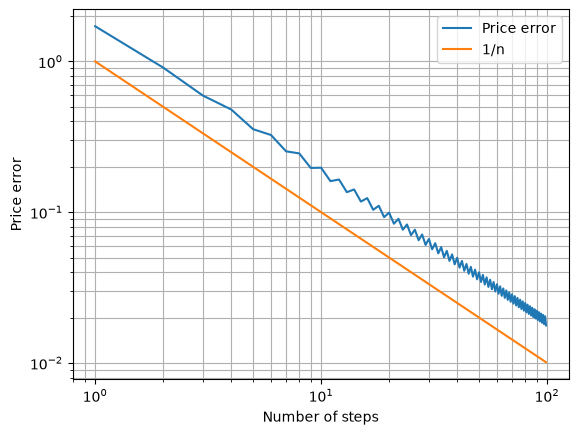

In [366]:
x = np.arange(1, 100)
y = [
    abs(
        european_option_binomial_model(
            S0=100, K=100, n=i, T=1, sigma=0.2, r=0.05, option_type="c"
        )[0]
        - black_scholes_option_pricer(
            S0=100, K=100, T=1, sigma=0.2, r=0.05, option_type="c"
        )[0]
    )
    for i in x
]

plt.loglog(x, y, label="Price error")
plt.loglog(x, [1 / k for k in x], label="1/n")
plt.xlabel("Number of steps")
plt.ylabel("Price error")
plt.grid(True, which="both")
plt.legend()
plt.show()
plt.close()